In [1]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe

In [2]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
lat_front_mean = np.nanmean(lat_front, axis = 0)

In [4]:
CrestTrough = sio.loadmat(path+'altimetry_meander_amplitude_dailydata_1993_2019_3m_30thrs.mat')
time        = CrestTrough['meand_time'][0]
trough_lat, trough_lon = CrestTrough['meand_pks_lat'], CrestTrough['meand_pks_lon']
crest_lat,  crest_lon  = CrestTrough['meand_trghs_lat'], CrestTrough['meand_trghs_lon']

In [5]:
from datetime import datetime
from datetime import timedelta
import pandas as pd

time_diff = np.cumsum(np.append(0, time[1:]-time[:-1]))
dates = np.array([])
for t in range(len(time)):
    dates = np.append(dates, datetime(1993,1,15) + timedelta(days=int(time_diff[t])))
dates = pd.to_datetime(dates)

## I need to sort the data in longitudinal bins to evaluate the changes in time
I found out that the dataset defined things as crest and trough without them necessarily being crests and troughs

In [159]:
cond1_trough = np.argwhere(trough_lon < 25)
cond1_crest  = np.argwhere(crest_lon < 25)
lon_group1   = np.array([trough_lon[cond1_trough[i][0], cond1_trough[i][1]] for i in range(len(cond1_trough))])
lon_group1   = np.append(lon_group1, [crest_lon[cond1_crest[i][0], cond1_crest[i][1]] for i in range(len(cond1_crest))])
##########################################################################################################################
cond2_trough = np.argwhere((trough_lon > 25) & (trough_lon < 28))
cond2_crest  = np.argwhere((crest_lon > 25) & (crest_lon < 28))
lon_group2   = np.array([trough_lon[cond2_trough[i][0], cond2_trough[i][1]] for i in range(len(cond2_trough))])
lon_group2   = np.append(lon_group2, [crest_lon[cond2_crest[i][0], cond2_crest[i][1]] for i in range(len(cond2_crest))])
##########################################################################################################################
cond3_trough = np.argwhere((trough_lon > 28) & (trough_lon < 32))
cond3_crest  = np.argwhere((crest_lon > 28) & (crest_lon < 32))
lon_group3   = np.array([trough_lon[cond3_trough[i][0], cond3_trough[i][1]] for i in range(len(cond3_trough))])
lon_group3   = np.append(lon_group3, [crest_lon[cond3_crest[i][0], cond3_crest[i][1]] for i in range(len(cond3_crest))])
##########################################################################################################################
cond4_trough = np.argwhere((trough_lon > 32) & (trough_lon < 34))
cond4_crest  = np.argwhere((crest_lon > 32) & (crest_lon < 34))
lon_group4   = np.array([trough_lon[cond4_trough[i][0], cond4_trough[i][1]] for i in range(len(cond4_trough))])
lon_group4   = np.append(lon_group4, [crest_lon[cond4_crest[i][0], cond4_crest[i][1]] for i in range(len(cond4_crest))])
##########################################################################################################################
cond5_trough = np.argwhere((trough_lon > 34) & (trough_lon < 37))
cond5_crest  = np.argwhere((crest_lon > 34) & (crest_lon < 37))
lon_group5   = np.array([trough_lon[cond5_trough[i][0], cond5_trough[i][1]] for i in range(len(cond5_trough))])
lon_group5   = np.append(lon_group5, [crest_lon[cond5_crest[i][0], cond5_crest[i][1]] for i in range(len(cond5_crest))])
##########################################################################################################################
cond6_trough = np.argwhere((trough_lon > 37) & (trough_lon < 41))
cond6_crest  = np.argwhere((crest_lon > 37) & (crest_lon < 41))
lon_group6   = np.array([trough_lon[cond6_trough[i][0], cond6_trough[i][1]] for i in range(len(cond6_trough))])
lon_group6   = np.append(lon_group6, [crest_lon[cond6_crest[i][0], cond6_crest[i][1]] for i in range(len(cond6_crest))])
##########################################################################################################################
cond7_trough = np.argwhere((trough_lon > 41) & (trough_lon < 44.5))
cond7_crest  = np.argwhere((crest_lon > 41) & (crest_lon < 44.5))
lon_group7   = np.array([trough_lon[cond7_trough[i][0], cond7_trough[i][1]] for i in range(len(cond7_trough))])
lon_group7   = np.append(lon_group7, [crest_lon[cond7_crest[i][0], cond7_crest[i][1]] for i in range(len(cond7_crest))])
##########################################################################################################################
cond8_trough = np.argwhere((trough_lon > 44.5) & (trough_lon < 52))
cond8_crest  = np.argwhere((crest_lon > 44.5) & (crest_lon < 52))
lon_group8   = np.array([trough_lon[cond8_trough[i][0], cond8_trough[i][1]] for i in range(len(cond8_trough))])
lon_group8   = np.append(lon_group8, [crest_lon[cond8_crest[i][0], cond8_crest[i][1]] for i in range(len(cond8_crest))])
##########################################################################################################################
cond9_trough = np.argwhere((trough_lon > 52) & (trough_lon < 56))
cond9_crest  = np.argwhere((crest_lon > 52) & (crest_lon < 56))
lon_group9   = np.array([trough_lon[cond9_trough[i][0], cond9_trough[i][1]] for i in range(len(cond9_trough))])
lon_group9   = np.append(lon_group9, [crest_lon[cond9_crest[i][0], cond9_crest[i][1]] for i in range(len(cond9_crest))])
##########################################################################################################################
cond10_trough = np.argwhere((trough_lon > 58) & (trough_lon < 65))
cond10_crest  = np.argwhere((crest_lon > 58) & (crest_lon < 65))
lon_group10   = np.array([trough_lon[cond10_trough[i][0], cond10_trough[i][1]] for i in range(len(cond10_trough))])
lon_group10   = np.append(lon_group10, [crest_lon[cond10_crest[i][0], cond10_crest[i][1]] for i in range(len(cond10_crest))])
##########################################################################################################################
cond11_trough = np.argwhere((trough_lon > 65) & (trough_lon < 66.5))
cond11_crest  = np.argwhere((crest_lon > 65) & (crest_lon < 66.5))
lon_group11   = np.array([trough_lon[cond11_trough[i][0], cond11_trough[i][1]] for i in range(len(cond11_trough))])
lon_group11   = np.append(lon_group11, [crest_lon[cond11_crest[i][0], cond11_crest[i][1]] for i in range(len(cond11_crest))])
##########################################################################################################################
cond12_trough = np.argwhere((trough_lon > 67) & (trough_lon < 70))
cond12_crest  = np.argwhere((crest_lon > 67) & (crest_lon < 70))
lon_group12   = np.array([trough_lon[cond12_trough[i][0], cond12_trough[i][1]] for i in range(len(cond12_trough))])
lon_group12   = np.append(lon_group12, [crest_lon[cond12_crest[i][0], cond12_crest[i][1]] for i in range(len(cond12_crest))])

## Doing the same for the latitudinal bins

In [160]:
##########################################################################################################################
lat_group1   = np.array([trough_lat[cond1_trough[i][0], cond1_trough[i][1]] for i in range(len(cond1_trough))])
lat_group1   = np.append(lat_group1, [crest_lat[cond1_crest[i][0], cond1_crest[i][1]] for i in range(len(cond1_crest))])
##########################################################################################################################
lat_group2   = np.array([trough_lat[cond2_trough[i][0], cond2_trough[i][1]] for i in range(len(cond2_trough))])
lat_group2   = np.append(lat_group2, [crest_lat[cond2_crest[i][0], cond2_crest[i][1]] for i in range(len(cond2_crest))])
##########################################################################################################################
lat_group3   = np.array([trough_lat[cond3_trough[i][0], cond3_trough[i][1]] for i in range(len(cond3_trough))])
lat_group3   = np.append(lat_group3, [crest_lat[cond3_crest[i][0], cond3_crest[i][1]] for i in range(len(cond3_crest))])
##########################################################################################################################
lat_group4   = np.array([trough_lat[cond4_trough[i][0], cond4_trough[i][1]] for i in range(len(cond4_trough))])
lat_group4   = np.append(lat_group4, [crest_lat[cond4_crest[i][0], cond4_crest[i][1]] for i in range(len(cond4_crest))])
##########################################################################################################################
lat_group5   = np.array([trough_lat[cond5_trough[i][0], cond5_trough[i][1]] for i in range(len(cond5_trough))])
lat_group5   = np.append(lat_group5, [crest_lat[cond5_crest[i][0], cond5_crest[i][1]] for i in range(len(cond5_crest))])
##########################################################################################################################
lat_group6   = np.array([trough_lat[cond6_trough[i][0], cond6_trough[i][1]] for i in range(len(cond6_trough))])
lat_group6   = np.append(lat_group6, [crest_lat[cond6_crest[i][0], cond6_crest[i][1]] for i in range(len(cond6_crest))])
##########################################################################################################################
lat_group7   = np.array([trough_lat[cond7_trough[i][0], cond7_trough[i][1]] for i in range(len(cond7_trough))])
lat_group7   = np.append(lat_group7, [crest_lat[cond7_crest[i][0], cond7_crest[i][1]] for i in range(len(cond7_crest))])
##########################################################################################################################
lat_group8   = np.array([trough_lat[cond8_trough[i][0], cond8_trough[i][1]] for i in range(len(cond8_trough))])
lat_group8   = np.append(lat_group8, [crest_lat[cond8_crest[i][0], cond8_crest[i][1]] for i in range(len(cond8_crest))])
##########################################################################################################################
lat_group9   = np.array([trough_lat[cond9_trough[i][0], cond9_trough[i][1]] for i in range(len(cond9_trough))])
lat_group9   = np.append(lat_group9, [crest_lat[cond9_crest[i][0], cond9_crest[i][1]] for i in range(len(cond9_crest))])
##########################################################################################################################
lat_group10   = np.array([trough_lat[cond10_trough[i][0], cond10_trough[i][1]] for i in range(len(cond10_trough))])
lat_group10   = np.append(lat_group10, [crest_lat[cond10_crest[i][0], cond10_crest[i][1]] for i in range(len(cond10_crest))])
##########################################################################################################################
lat_group11   = np.array([trough_lat[cond11_trough[i][0], cond11_trough[i][1]] for i in range(len(cond11_trough))])
lat_group11   = np.append(lat_group11, [crest_lat[cond11_crest[i][0], cond11_crest[i][1]] for i in range(len(cond11_crest))])
##########################################################################################################################
lat_group12   = np.array([trough_lat[cond12_trough[i][0], cond12_trough[i][1]] for i in range(len(cond12_trough))])
lat_group12   = np.append(lat_group12, [crest_lat[cond12_crest[i][0], cond12_crest[i][1]] for i in range(len(cond12_crest))])

## Now, we need to find the time (or index) of each event to sort it out

In [220]:
########################################################################################################
idx_cond1 = np.array([cond1_trough[i, 1] for i in range(len(cond1_trough))])
idx_cond1 = np.append(idx_cond1, [cond1_crest[i, 1] for i in range(len(cond1_crest))])
########################################################################################################
idx_cond2 = np.array([cond2_trough[i, 1] for i in range(len(cond2_trough))])
idx_cond2 = np.append(idx_cond2, [cond2_crest[i, 1] for i in range(len(cond2_crest))])
########################################################################################################
idx_cond3 = np.array([cond3_crest[i, 1] for i in range(len(cond3_crest))])
# idx_cond3 = np.append(idx_cond3, [cond3_crest[i, 1] for i in range(len(cond3_crest))])
########################################################################################################
idx_cond4 = np.array([cond4_trough[i, 1] for i in range(len(cond4_trough))])
# idx_cond4 = np.append(idx_cond4, [cond4_crest[i, 1] for i in range(len(cond4_crest))])
########################################################################################################
idx_cond5 = np.array([cond5_crest[i, 1] for i in range(len(cond5_crest))])
# idx_cond5 = np.append(idx_cond5, [cond5_crest[i, 1] for i in range(len(cond5_crest))])
########################################################################################################
idx_cond6 = np.array([cond6_trough[i, 1] for i in range(len(cond6_trough))])
idx_cond6 = np.append(idx_cond6, [cond6_crest[i, 1] for i in range(len(cond6_crest))])
########################################################################################################
idx_cond7 = np.array([cond7_trough[i, 1] for i in range(len(cond7_trough))])
idx_cond7 = np.append(idx_cond7, [cond7_crest[i, 1] for i in range(len(cond7_crest))])
########################################################################################################
idx_cond8 = np.array([cond8_trough[i, 1] for i in range(len(cond8_trough))])
idx_cond8 = np.append(idx_cond8, [cond8_crest[i, 1] for i in range(len(cond8_crest))])
########################################################################################################
idx_cond9 = np.array([cond9_trough[i, 1] for i in range(len(cond9_trough))])
idx_cond9 = np.append(idx_cond9, [cond9_crest[i, 1] for i in range(len(cond9_crest))])
########################################################################################################
idx_cond10 = np.array([cond10_trough[i, 1] for i in range(len(cond10_trough))])
idx_cond10 = np.append(idx_cond10, [cond10_crest[i, 1] for i in range(len(cond10_crest))])
########################################################################################################
idx_cond11 = np.array([cond11_trough[i, 1] for i in range(len(cond11_trough))])
# idx_cond11 = np.append(idx_cond11, [cond11_crest[i, 1] for i in range(len(cond11_crest))])
########################################################################################################
idx_cond12 = np.array([cond12_trough[i, 1] for i in range(len(cond12_trough))])
idx_cond12 = np.append(idx_cond12, [cond12_crest[i, 1] for i in range(len(cond12_crest))])

In [281]:
#############################################################################################
idx_conditions = [idx_cond1, idx_cond2, idx_cond3, idx_cond4,  idx_cond5,  idx_cond6,
                  idx_cond7, idx_cond8, idx_cond9, idx_cond10, idx_cond11, idx_cond12]
#############################################################################################
lat_groups     = [lat_group1, lat_group2, lat_group3, lat_group4,  lat_group5,  lat_group6,
                  lat_group7, lat_group8, lat_group9, lat_group10, lat_group11, lat_group12]
#############################################################################################
lon_groups     = [lon_group1, lon_group2, lon_group3, lon_group4,  lon_group5,  lon_group6,
                  lon_group7, lon_group8, lon_group9, lon_group10, lon_group11, lon_group12]

In [308]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'k', 'tab:red', 'tab:purple',
          'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'lime']

## Figures

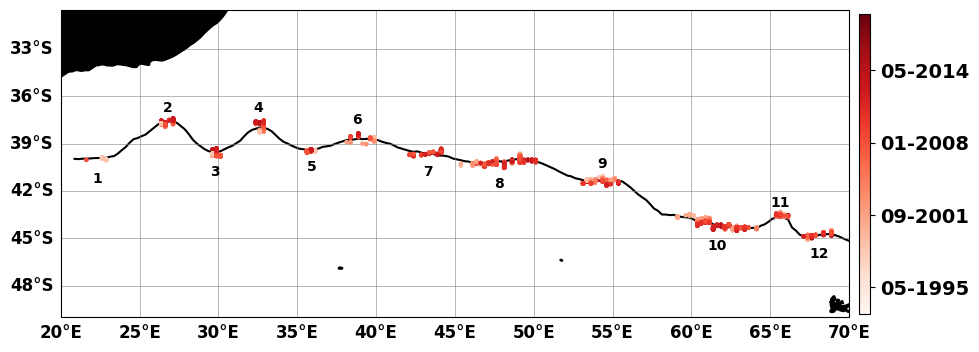

In [271]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [19.99, 70.01, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree())

ax.plot(lon_front, lat_front_mean, color = 'k', linewidth = 1.5)
for i in range(len(trough_lon)):
    cf = ax.scatter(trough_lon[i], trough_lat[i], c = pd.to_datetime(dates), cmap = 'Reds', s = 5, zorder = 10,
               vmin = np.array('1993-01-15T00:00:00.000000000', dtype='datetime64[ns]'),
               vmax = np.array('2019-05-01T00:00:00.000000000', dtype='datetime64[ns]'))

    ax.scatter(crest_lon[i], crest_lat[i], c = pd.to_datetime(dates), cmap = 'Reds', s = 5, zorder = 10,
               vmin = np.array('1993-01-15T00:00:00.000000000', dtype='datetime64[ns]'),
               vmax = np.array('2019-05-01T00:00:00.000000000', dtype='datetime64[ns]'))

##
ax.annotate(text='1', xy=(22, -41.5), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='2', xy=(26.5, -37), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='3', xy=(29.5, -41), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='4', xy=(32.2, -37), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='5', xy=(35.6, -40.7), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='6', xy=(38.5, -37.7), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='7', xy=(43, -41), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='8', xy=(47.5, -41.8), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='9', xy=(54, -40.5), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='10', xy=(61, -45.7), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='11', xy=(65, -43), xycoords='data', fontsize = 10, color = 'k')
ax.annotate(text='12', xy=(67.5, -46.2), xycoords='data', fontsize = 10, color = 'k')

ax.set_extent(extent, ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax.gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
gl.left_labels = True
if i > 0 :
    gl.bottom_labels = True
gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
gl.ylabel_style = {'size': 12}
gl.xlabel_style = {'size': 12}

# Add a colorbar
cbaxes = fig.add_axes([0.88, 0.5, 0.01, 0.375]) 
cbar = plt.colorbar(cf, cax = cbaxes)

# Fix the colorbar ticks
# We need pandas for this
cbar.ax.set_yticklabels(pd.to_datetime(cbar.get_ticks()).strftime(date_format='%m-%Y'));

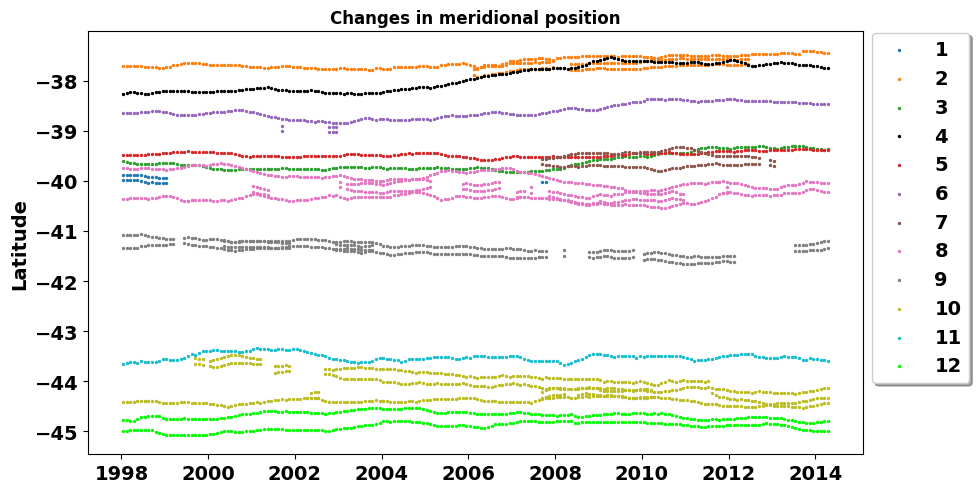

In [313]:
fig = plt.figure(figsize = (10,10))

ax = [fig.add_subplot(grd[:55,:])]   

[ax[0].scatter(dates[idx_conditions[i]], lat_groups[i], s = 2, label = str(i+1), color =colors[i]) 
 for i in range(len(lat_groups))]

ax[0].set_ylabel('Latitude')
ax[0].set_title('Changes in meridional position', fontsize = 12)
ax[0].legend(facecolor = 'w', shadow=True, bbox_to_anchor=(1.15, 1.02))

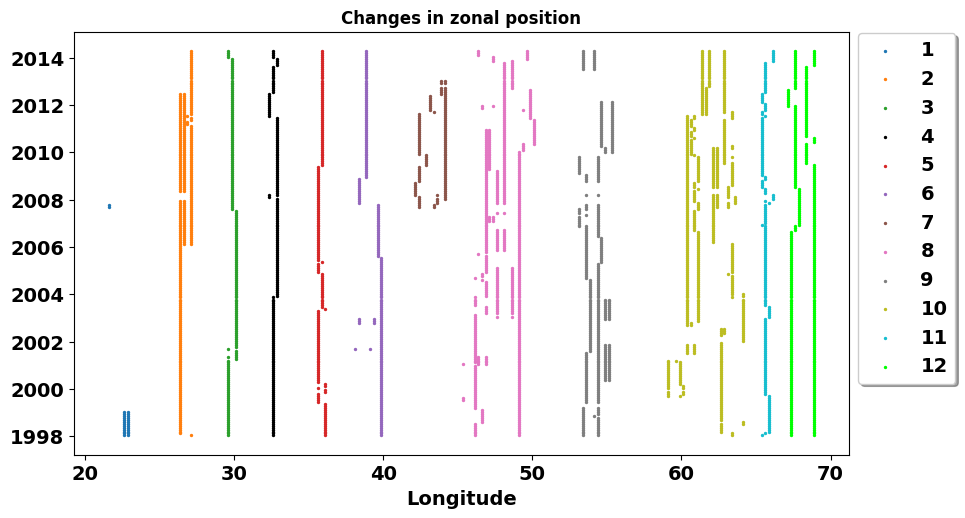

In [314]:
fig = plt.figure(figsize = (10,10))

ax = [fig.add_subplot(grd[:55,:])]   

[ax[0].scatter(lon_groups[i], dates[idx_conditions[i]], s = 2, label = str(i+1), color =colors[i]) for i in range(len(lat_groups))]

ax[0].set_xlabel('Longitude')
ax[0].set_title('Changes in zonal position', fontsize = 12)
ax[0].legend(facecolor = 'w', shadow=True, bbox_to_anchor=(1.15, 1.02))

## First analysis: without organizing the trough and crest regions

Text(0.5, 1.0, 'Changes in zonal position of the crest')

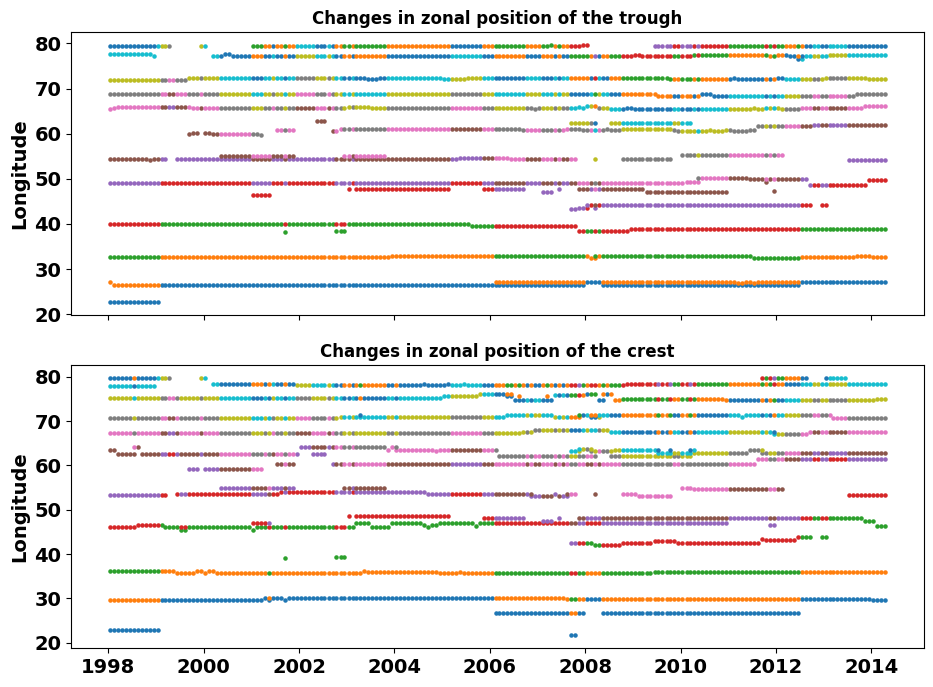

In [125]:
fig = plt.figure(figsize = (11,8))

ax = [fig.add_subplot(grd[:46,:]), fig.add_subplot(grd[54:,:])]   

for i in range(len(trough_lat)):
    ax[0].scatter(dates, trough_lon[i], s = 5)
    ax[1].scatter(dates, crest_lon[i], s = 5)
    if i < 2:
        ax[i].set_ylabel('Longitude')

ax[0].set_xticklabels([])
ax[0].set_title('Changes in zonal position of the trough', fontsize = 12)
ax[1].set_title('Changes in zonal position of the crest', fontsize = 12)

Text(0.5, 1.0, 'Changes in meridional position of the crest')

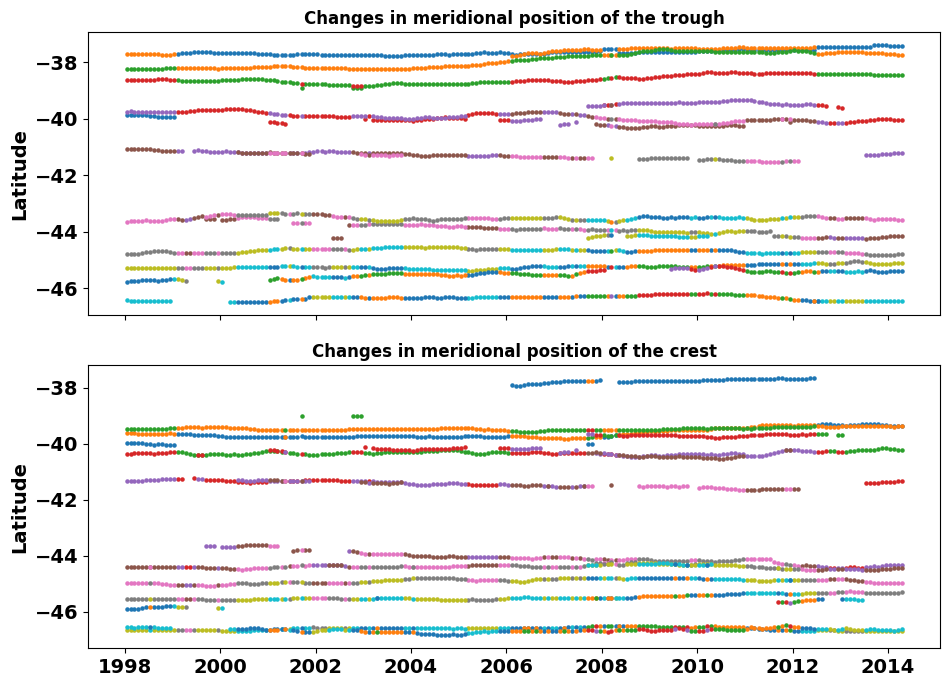

In [126]:
fig = plt.figure(figsize = (11,8))

ax = [fig.add_subplot(grd[:46,:]), fig.add_subplot(grd[54:,:])]   

for i in range(len(trough_lat)):
    ax[0].scatter(dates, trough_lat[i], s = 5)
    ax[1].scatter(dates, crest_lat[i], s = 5)
    if i < 2:
        ax[i].set_ylabel('Latitude')

ax[0].set_xticklabels([])
ax[0].set_title('Changes in meridional position of the trough', fontsize = 12)
ax[1].set_title('Changes in meridional position of the crest', fontsize = 12)